# 3.word2vec

### 神经网络中处理单词方法

In [ ]:
import numpy as np

c = np.array([[1,0,0,0,0,0,0]])
W = np.random.randn(7, 3)
h = np.dot(c,W)
print(h) # 省略偏置


[[0.10499575 0.83200032 0.81718084]]


In [2]:
import sys
sys.path.append('./res')
import numpy as np
from common.layers import MatMul

c = np.array([[1,0,0,0,0,0,0]])
W = np.random.randn(7,3)
layer = MatMul(W)
''' 
class MatMul:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.x = None

    def forward(self, x):
        W, =self.params
        out = np.dot(x,W)
        self.x = x
        return out

    def backward(self, dout):
        W, = self.params
        dx = np.dot(dout, W.T)
        dW = np.dot(self.x.T, dout)
        self.grads[0][...] = dW
        return dx
'''

h = layer.forward(c)
print(h)


[[-0.39019119  0.10598804 -0.89591076]]


### 简单的word2vec
continuous bag-of-words(`CBOW`):根据上下文预测目标词的神经网络

In [2]:
# CBOW 模型的推理
import sys
sys.path.append('./res')
import numpy as np
from common.layers import MatMul

# 样本的上下文数据
c0 = np.array([[1,0,0,0,0,0,0]])
c1 = np.array([[0,0,1,0,0,0,0]])

#权重的初始值
W_in = np.random.randn(7,3)
W_out = np.random.randn(3,7)

# 生成层
in_layer0 = MatMul(W_in)
in_layer1 = MatMul(W_in)
out_layer = MatMul(W_out)

#正向传播
h0 = in_layer0.forward(c0)
h1 = in_layer1.forward(c1)
h = 0.5 * (h0 + h1)
s = out_layer.forward(h)

print(s)

[[ 2.81094255 -0.98564275  0.76601053 -1.37143502 -0.67154748 -1.60241308
  -1.14820431]]


### CBOW的学习
|corpus|contexts|target|
|:---|:---|:---|
|you `say` goodbye and i say hello.|you,goodbye|say|
|you say `goodbye` and i say hello.|say,and|goodbye|
|you say goodbye `and` i say hello.|goodbye,i|and|
|you say goodbye and `i` say hello.|and,say|i|
|you say goodbye and i `say` hello.|i,hello|say|
|you say goodbye and i say `hello`.|say,.|hello|

In [ ]:
import sys
sys.path.append('./res')
from common.util import preprocess

text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)
''' 
def preprocess(text):
    text = text.lower()
    text = text.replace('.', ' .')
    words = text.split(' ')

    word_to_id = {}
    id_to_word = {}

    for word in words:
        if word not in word_to_id:
            new_id = len(word_to_id)
            word_to_id[word] = new_id
            id_to_word[new_id] = word

    corpus = np.array([word_to_id[w] for w in words])
    return corpus, word_to_id, id_to_word
'''
print(corpus)
print(id_to_word)

[0 1 2 3 4 1 5 6]
{0: 'you', 1: 'say', 2: 'goodbye', 3: 'and', 4: 'i', 5: 'hello', 6: '.'}


In [ ]:
def create_contexts_target(corpus, window_size=1):
    ''' 
    params:
    :corpus:词序列
    :window_size:上下文窗口大小(左右各取多少词)
    '''
    target = corpus[window_size:-window_size] # 去掉第window_size和倒数第window_size为止的词之后将其作为目标
    contexts = [] # 存储每个目标词对应的上下文词列表

    for idx in range(window_size, len(corpus)- window_size): # 同target索引范围。因为range不能用列表索引固写的繁琐
        cs=[] # 存储当前中心词的上下文
        for t in range(-window_size, window_size + 1): # 生成-1到1的连续整数
        # 实现左右取词
            if t == 0: # 略过当前词本身
                continue
            cs.append(corpus[idx + t])
        contexts.append(cs)

    return np.array(contexts), np.array(target)

In [6]:
contexts, target = create_contexts_target(corpus, window_size=1)
print(contexts)
print('-'*20)
print(target)

[[0 2]
 [1 3]
 [2 4]
 [3 1]
 [4 5]
 [1 6]]
--------------------
[1 2 3 4 1 5]


In [ ]:
import sys
sys.path.append('./res')
from common.util import preprocess, create_contexts_target, convert_one_hot
"""
def convert_one_hot(corpus, vocab_size):
    '''转换为one-hot表示

    :param corpus: 单词ID列表（一维或二维的NumPy数组）
    :param vocab_size: 词汇个数
    :return: one-hot表示（二维或三维的NumPy数组）
    '''
    N = corpus.shape[0]

    if corpus.ndim == 1:
        one_hot = np.zeros((N, vocab_size), dtype=np.int32)
        for idx, word_id in enumerate(corpus):
            one_hot[idx, word_id] = 1

    elif corpus.ndim == 2:
        C = corpus.shape[1]
        one_hot = np.zeros((N, C, vocab_size), dtype=np.int32)
        for idx_0, word_ids in enumerate(corpus):
            for idx_1, word_id in enumerate(word_ids):
                one_hot[idx_0, idx_1, word_id] = 1

    return one_hot
"""


text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)

contexts, target = create_contexts_target(corpus, window_size=1)

vocab_size = len(word_to_id)
target = convert_one_hot(target, vocab_size)
contexts = convert_one_hot(contexts, vocab_size)

In [13]:
import sys
sys.path.append('./res')
import numpy as np
from common.layers import MatMul, SoftmaxWithLoss

class SimpleCBOW:
    def __init__(self, vocab_size, hidden_size):
        V, H = vocab_size, hidden_size
        
        # 初始化权重
        W_in = 0.01 * np.random.randn(V, H).astype('f')
        W_out = 0.01 * np.random.randn(H, V).astype('f')

        # 生成层
        self.in_layer0 = MatMul(W_in)
        self.in_layer1 = MatMul(W_in)
        self.out_layer = MatMul(W_out)
        ''' 
        class MatMul:
            def __init__(self, W):
                self.params = [W]
                self.grads = [np.zeros_like(W)]
                self.x = None

            def forward(self, x):
                W, = self.params
                out = np.dot(x,W)
                self.x = x
                return out

            def backward(self, dout):
                W, = self.params
                dx = np.dot(dout, W.T)
                dW = np.dot(self.x.T, dout)
                self.grads[0][...] = dW
                return dx
        '''
        self.loss_layer = SoftmaxWithLoss()

        # 将所有权重和梯度整理到列表
        layers = [self.in_layer0, self.in_layer1, self.out_layer]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        # 将单词的分布式表示设置为成员变量
        self.word_vecs = W_in

    def forward(self, contexts, target):
        h0 = self.in_layer0.forward(contexts[:,0]) # contexts所有行，第0列
        h1 = self.in_layer1.forward(contexts[:,1])
        h = (h0 + h1) * 0.5
        score = self.out_layer.forward(h)
        loss = self.loss_layer.forward(score, target)
        return loss
    
    def backward(self, dout=1):
        ds = self.loss_layer.backward(dout)
        da = self.out_layer.backward(ds)
        da *= 0.5
        self.in_layer1.backward(da)
        self.in_layer0.backward(da)
        return None

| epoch 1 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 2 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 3 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 4 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 5 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 6 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 7 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 8 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 9 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 10 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 11 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 12 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 13 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 14 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 15 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 16 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 17 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 18 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 19 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 20 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 21 |  iter 1 / 2 | ti

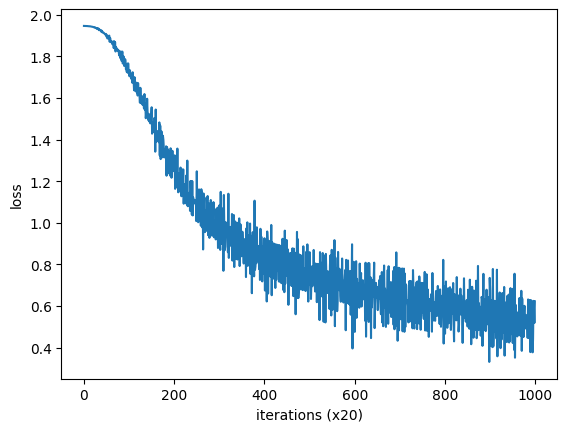

In [14]:
import sys
sys.path.append('./res')
from common.trainer import Trainer
from common.optimizer import Adam
from common.util import preprocess, create_contexts_target, convert_one_hot

window_size = 1
hidden_size = 5
batch_size = 3
max_epoch = 1000

text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)

vocab_size = len(word_to_id)
contexts, target = create_contexts_target(corpus, window_size)
target = convert_one_hot(target, vocab_size)
contexts = convert_one_hot(contexts, vocab_size)

model = SimpleCBOW(vocab_size, hidden_size)
optimizer = Adam()
trainer = Trainer(model, optimizer)
trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()

In [15]:
word_vecs = model.word_vecs
for word_id, word in id_to_word.items():
    print(word, word_vecs[word_id])

you [-1.254561   -1.5088539   0.9821545  -0.86204654 -1.0469604 ]
say [ 0.01742847 -1.1959902  -1.1719543   1.1665846   1.1464533 ]
goodbye [-0.5246098  -0.29019928  0.9971894  -1.0823283  -0.9216833 ]
and [-1.9151332  0.5866748 -1.1285874  1.0873542  1.0842676]
i [-0.5000321  -0.27436233  0.98491323 -1.0647547  -0.9027874 ]
hello [-1.2728148  -1.5127996   0.9820829  -0.85836434 -1.0321348 ]
. [ 1.6134474  -1.4741144  -0.85003364  0.8956865   0.8741287 ]
